In [ ]:
from openai import OpenAI

api_key="YOUR_OPENAI_API_KEY"
client = OpenAI(api_key=api_key)

In [3]:
image_path = r"train_station.jpeg"

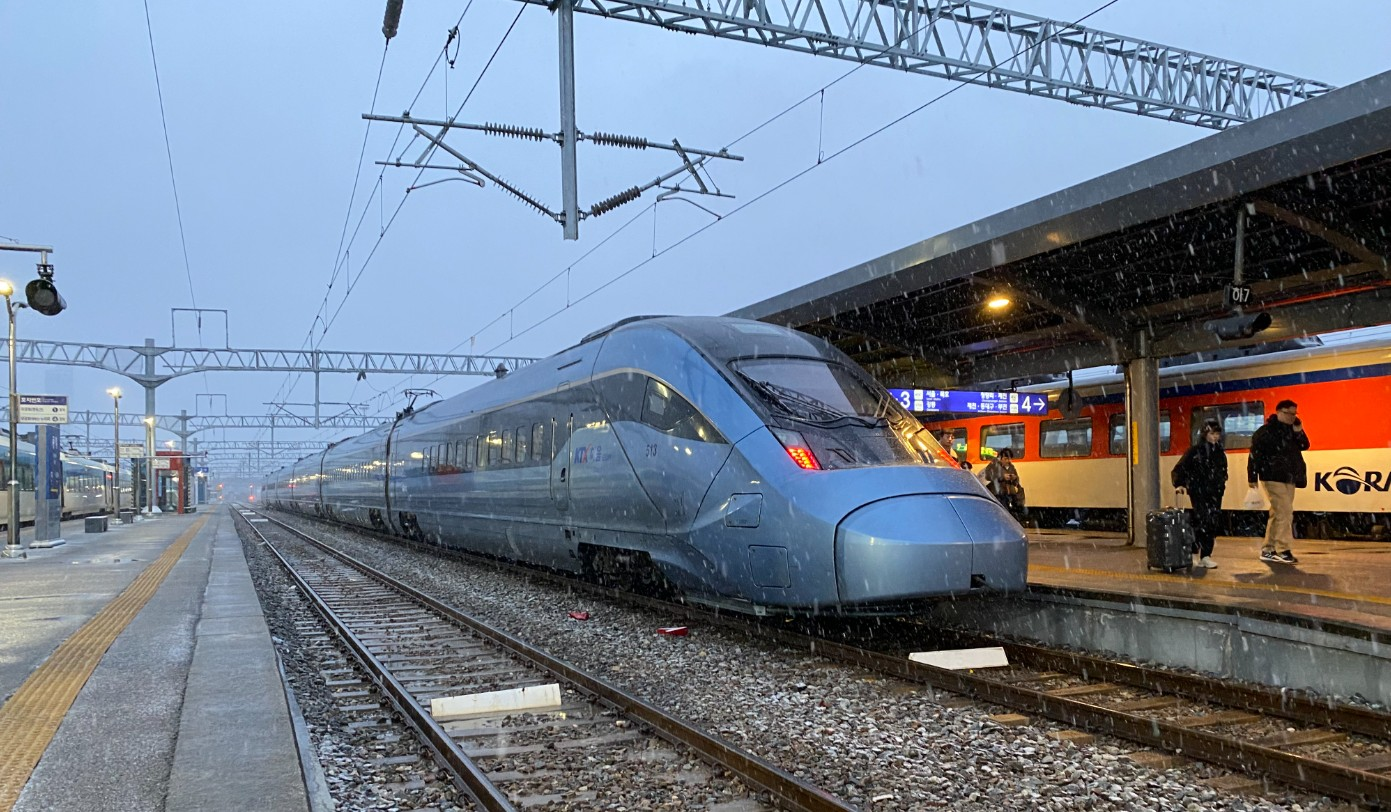

In [4]:
# 이미지를 노트북에 표시

from IPython.display import Image
Image(filename=image_path)


In [5]:
import base64

def encode_image(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode('utf-8')

base64_image = encode_image(image_path)

In [6]:
response = client.chat.completions.create(
    model="gpt-5.4-mini-2026-03-17",
    messages=[
        {
            "role": "user",
            "content": [
                {
                    "type": "text",
                    "text": "사진에 무엇이 있나요?"
                },
                {
                    "type": "image_url",
                    "image_url": {
                        "url": f"data:image/jpeg;base64,{base64_image}"
                    }
                }
            ]
        }
    ]
)

In [7]:
print(response.choices[0])

Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='사진에는 **기차역 플랫폼**에 선 **KTX 고속열차**가 보입니다.  \n오른쪽에는 **다른 코레일 열차**와 **승객들**, 위에는 **전차선/전기 설비**가 있고, 바닥과 공기에는 **눈이 내리는 모습**이 보입니다. 전체적으로 **눈 오는 날의 기차역 풍경**입니다.', refusal=None, role='assistant', annotations=[], audio=None, function_call=None, tool_calls=None))


In [8]:
print(response.choices[0].message.content)

사진에는 **기차역 플랫폼**에 선 **KTX 고속열차**가 보입니다.  
오른쪽에는 **다른 코레일 열차**와 **승객들**, 위에는 **전차선/전기 설비**가 있고, 바닥과 공기에는 **눈이 내리는 모습**이 보입니다. 전체적으로 **눈 오는 날의 기차역 풍경**입니다.


In [11]:
response = client.chat.completions.create(
    model="gpt-5.4-mini-2026-03-17",
    messages=[
        {
            "role": "user",
            "content": [
                {
                    "type": "text",
                    "text": "사진 속 열차의 모델이 무엇인가요?"
                },
                {
                    "type": "image_url",
                    "image_url": {
                        "url": f"data:image/jpeg;base64,{base64_image}"
                    }
                }
            ]
        }
    ]
)

In [12]:
print(response.choices[0].message.content)

사진 속 열차는 **코레일 KTX-이음**으로 보입니다.

근거:
- 차량 측면에 **KTX** 로고가 보임
- 앞부분이 **유선형의 푸른 회색 도색**이며, KTX-이음 특유의 디자인과 잘 맞음
- 짧은 객차 연결부와 전체적인 형상이 **KTX-이음(EMU-260)** 계열과 유사함

다만 사진 각도 때문에 100% 단정은 어렵지만, **가장 유력한 모델은 KTX-이음**입니다.
